In [1]:
import holidays

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
import plotly.io as pio

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler   # u otros scalers
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import KNNImputer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline

from geopy.distance import geodesic #mide distancia a partir de longitud y latitud

In [2]:
# carga datos de dataset en dataframe
file_path= 'uber_fares.csv'

df = pd.read_csv(file_path)

In [3]:
# trabajamos sobre una copia del df
df_copy = df.copy()

In [4]:
df_copy.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


## Ejercicio 3: Análisis descriptivo y exhaustivo

#### Datos Faltantes 

In [5]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [6]:
df.isnull().any(axis=1).sum()

np.int64(1)

In [7]:
# como solo hay un registro con variables nulas, lo eliminamos
df_copy.dropna(subset=['dropoff_longitude', 'dropoff_latitude'], inplace=True)

# llevamos un contador de los registros eliminados
eliminados = 0
eliminados += 1

In [8]:
df_copy.isnull().sum()

key                  0
date                 0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

#### **Variable Pasajeros**

In [9]:
df_copy['passenger_count'].value_counts()

passenger_count
1      138425
2       29428
5       14009
3        8881
4        4276
6        4271
0         708
208         1
Name: count, dtype: int64

In [10]:
# Eliminamos el registro con mas de 6 pasajeros ya que es solo uno
df_copy.drop(df_copy[df_copy['passenger_count'] > 6].index, inplace=True)
eliminados += 1

In [11]:
# Creamos columnas booleanas para los tipos de uber segun cantidad de pasajeros 
df_copy['uber_eats'] = (df_copy['passenger_count'] == 0).astype(int)
df_copy['uber_normal'] = ((df_copy['passenger_count'] >= 1) & (df_copy['passenger_count'] < 5)).astype(int)
df_copy['uber_xl'] = (df_copy['passenger_count'] >= 5).astype(int)

#### **Variable Fecha**

In [12]:
# Convertimos la columna 'pickup_datetime' a tipo datetime para luego poder dividir los datos en Año, Mes, dia, hora, dia de la semana

df_copy['pickup_datetime'] = pd.to_datetime(df_copy['pickup_datetime'])

df_copy["year"] = df_copy["pickup_datetime"].dt.year
df_copy["month"] = df_copy["pickup_datetime"].dt.month
df_copy["day"] = df_copy["pickup_datetime"].dt.day
df_copy["hour"] = df_copy["pickup_datetime"].dt.hour

df_copy["weekday"] = df_copy["pickup_datetime"].dt.weekday  # 0 = Lunes, 6 = Domingo
df_copy["weekend"] = ((df_copy["weekday"] == 6) | (df_copy['weekday'] == 5)).astype(int)


In [13]:
# Objeto con los feriados en EE.UU.
us_holidays = holidays.US()

# Agregamos columna con los dias feriados de EEUU. 0 = No es feriado. 1 = Es feriado
df_copy['feriado'] = df_copy['pickup_datetime'].dt.date.apply(lambda x: 1 if x in us_holidays else 0)

In [14]:
def clasificar_franja_corrida(hora):
    """ Clasificamos en una franja horaria determianda segun la hora"""
    if 1 <= hora <= 6:
        return 'madrugada'
    elif 7 <= hora <= 12:
        return 'mañana'
    elif 13 <= hora <= 18:
        return 'tarde'
    else:  # 0 y 19–24
        return 'noche'

df_copy['franja_horaria'] = df_copy['hour'].apply(clasificar_franja_corrida)

# Si luego se desea utilizar one-hot encoding
df_copy = pd.get_dummies(df_copy, columns=["franja_horaria"], dtype=int)

In [15]:
df_copy.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,uber_eats,...,month,day,hour,weekday,weekend,feriado,franja_horaria_madrugada,franja_horaria_mañana,franja_horaria_noche,franja_horaria_tarde
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,0,...,5,7,19,3,0,0,0,0,1,0
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,0,...,7,17,20,4,0,0,0,0,1,0
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,0,...,8,24,21,0,0,0,0,0,1,0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,0,...,6,26,8,4,0,0,0,1,0,0
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,0,...,8,28,17,3,0,0,0,0,0,1


In [16]:
df_copy.columns

Index(['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count', 'uber_eats', 'uber_normal', 'uber_xl', 'year',
       'month', 'day', 'hour', 'weekday', 'weekend', 'feriado',
       'franja_horaria_madrugada', 'franja_horaria_mañana',
       'franja_horaria_noche', 'franja_horaria_tarde'],
      dtype='object')

#### **Variables de Posición Geográfica**

In [17]:
# Observamos si hay coordenadas imposibles
df[['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']].describe()

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
count,200000.000000,200000.000000,199999.000000,199999.000000
mean,39.935885,-72.527638,39.923890,-72.525292
std,7.720539,11.437787,6.794829,13.117408
min,-74.015515,-1340.648410,-881.985513,-3356.666300
25%,40.734796,-73.992065,40.733823,-73.991407
50%,40.752592,-73.981823,40.753042,-73.980093
75%,40.767158,-73.967154,40.768001,-73.963658
max,1644.421482,57.418457,872.697628,1153.572603


In [18]:
def corregir_coordenadas(df):
    """
    Corrige coordenadas inválidas en el DataFrame.
    Si latitud está fuera de [-90, 90], se ajusta a 90 o -90.
    Si longitud está fuera de [-180, 180], se ajusta a 180 o -180.
    """

    # Corregimos pickup_latitude
    df['pickup_latitude'] = df['pickup_latitude'].apply(
        lambda x: 90 if x > 90 else (-90 if x < -90 else x)
    )
    
    # Corregimos dropoff_latitude
    df['dropoff_latitude'] = df['dropoff_latitude'].apply(
        lambda x: 90 if x > 90 else (-90 if x < -90 else x)
    )
    
    # Corregimos pickup_longitude
    df['pickup_longitude'] = df['pickup_longitude'].apply(
        lambda x: 180 if x > 180 else (-180 if x < -180 else x)
    )
    
    # Corregimos dropoff_longitude
    df['dropoff_longitude'] = df['dropoff_longitude'].apply(
        lambda x: 180 if x > 180 else (-180 if x < -180 else x)
    )
    
    return df

corregir_coordenadas(df_copy)

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,uber_eats,...,month,day,hour,weekday,weekend,feriado,franja_horaria_madrugada,franja_horaria_mañana,franja_horaria_noche,franja_horaria_tarde
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,0,...,5,7,19,3,0,0,0,0,1,0
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,0,...,7,17,20,4,0,0,0,0,1,0
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,0,...,8,24,21,0,0,0,0,0,1,0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,0,...,6,26,8,4,0,0,0,1,0,0
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,0,...,8,28,17,3,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,0,...,10,28,10,6,1,0,0,1,0,0
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,0,...,3,14,1,4,0,0,1,0,0,0
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,0,...,6,29,0,0,0,0,0,0,1,0
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,0,...,5,20,14,2,0,0,0,0,0,1


In [19]:
df_copy[['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']].describe()

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
count,199998.000000,199998.000000,199998.000000,199998.000000
mean,39.918967,-72.504921,39.921915,-72.511479
std,6.134335,10.473034,6.126444,10.432748
min,-74.015515,-180.000000,-90.000000,-180.000000
25%,40.734795,-73.992065,40.733823,-73.991407
50%,40.752592,-73.981823,40.753042,-73.980093
75%,40.767158,-73.967154,40.768001,-73.963659
max,90.000000,57.418457,90.000000,180.000000


In [20]:
# Visualizamos todos los puntos 

# Creamos dos DataFrames separados para pickups y dropoffs
df_pickup = df[['pickup_latitude', 'pickup_longitude']].copy()
df_pickup['tipo'] = 'pickup'
df_pickup.rename(columns={
    'pickup_latitude': 'latitude',
    'pickup_longitude': 'longitude'
}, inplace=True)

df_dropoff = df[['dropoff_latitude', 'dropoff_longitude']].copy()
df_dropoff['tipo'] = 'dropoff'
df_dropoff.rename(columns={
    'dropoff_latitude': 'latitude',
    'dropoff_longitude': 'longitude'
}, inplace=True)

# Unimos ambos DataFrames
df_coords = pd.concat([df_pickup, df_dropoff], ignore_index=True)

# Graficamos
fig = px.scatter_map(
    df_coords,
    lat="latitude",
    lon="longitude",
    color="tipo",  # Esta columna diferencia entre pickup y dropoff
    zoom=7,
    height=600,
    title="Ubicación de Pickups y Dropoffs",
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":30,"l":0,"b":0})
fig.show()


In [21]:
def calcular_distancia(row):
    pickup = (row['pickup_latitude'], row['pickup_longitude'])
    dropoff = (row['dropoff_latitude'], row['dropoff_longitude'])
    return geodesic(pickup, dropoff).kilometers

# Agregamos la columna 'distance' al DataFrame
df_copy['distance'] = df_copy.apply(calcular_distancia, axis=1)

In [22]:
# Definimos el área válida (NY y alrededores)
lat_min, lat_max = 38.5, 42.5
lon_min, lon_max = -77.5, -70.5

In [23]:
# Creamos una máscara para saber qué puntos están FUERA del área válida
pickup_fuera = ~df_copy['pickup_latitude'].between(lat_min, lat_max) | ~df_copy['pickup_longitude'].between(lon_min, lon_max)
dropoff_fuera = ~df_copy['dropoff_latitude'].between(lat_min, lat_max) | ~df_copy['dropoff_longitude'].between(lon_min, lon_max)

# Creamos condición final: distancia == 0 y ambos puntos fuera del área
condicion = (df_copy['distance'] == 0) & pickup_fuera & dropoff_fuera

# Estos datos seran eliminados ya que son 5 columnas que tienen datos erroneos y su imputacion puede llegar a sesgar el modelo
cantidad_a_eliminar = condicion.sum()
eliminados += cantidad_a_eliminar


In [24]:
# Eliminamos esos registros
df_copy = df_copy[~condicion]

# Aquellos datos que tienen al menos una coordenada fuera del area los marcamos con null para tratarlos despues del split train test
condicion_fuera_area = (pickup_fuera | dropoff_fuera) & (df_copy['distance'] != 0)
df_copy.loc[condicion_fuera_area, ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude', 'distance']] = np.nan

#### **Variable Target: Fare amount**

In [25]:
df_copy['fare_amount'].describe()

count    196406.000000
mean         11.350591
std           9.816649
min         -52.000000
25%           6.000000
50%           8.500000
75%          12.500000
max         499.000000
Name: fare_amount, dtype: float64

In [26]:
# Contamos los registros con fare_amount menores o iguales a 0 y mayores a 200
se_eliminan = df_copy[(df_copy['fare_amount'] <= 0) | (df_copy['fare_amount'] > 200)].shape[0]

# Imprimimos la cantidad de registros que se eliminarán
print(f'Se eliminarán {se_eliminan} registros.')
eliminados += se_eliminan

Se eliminarán 25 registros.


In [27]:
df_copy = df_copy[(df_copy['fare_amount'] >= 0) & (df_copy['fare_amount'] <= 200)]

In [28]:
porcentaje_eliminado = (eliminados / len(df)) * 100

print(f'Total de filas eliminadas: {eliminados}')
print(f'Porcentaje de filas eliminadas: {porcentaje_eliminado:.2f}%')

Total de filas eliminadas: 3619
Porcentaje de filas eliminadas: 1.81%


### Particionamos los datos en datos de entrenamiento y de testeo

In [29]:
# Definimos las features relevantes y la variable target
features = [
    'distance',
    'year',
    'month',
    'feriado',
    'weekday',
    'hour',
    'uber_eats',
    'uber_normal',
    'uber_xl',
    'franja_horaria_madrugada',
    'franja_horaria_mañana',
    'franja_horaria_tarde',
    'franja_horaria_noche',
    'pickup_latitude',
    'dropoff_latitude',
    'pickup_longitude',
    'dropoff_longitude',

]
target = 'fare_amount'

# Separamos en conjuntos de entrenamiento y prueba usando únicamente las features definidas
X_train, X_test, y_train, y_test = train_test_split(df_copy[features], df_copy[target], test_size=0.2, random_state=42)        

In [30]:
# Definimos las columnas que se imputarán
cols_imputar = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude', 'distance']

# Creamos el imputador KNN  con 5 vecinos
imputer = KNNImputer(n_neighbors=5)
X_train[cols_imputar] = imputer.fit_transform(X_train[cols_imputar])
X_test[cols_imputar] = imputer.transform(X_test[cols_imputar])

In [31]:
# IMPUTAMOS LAS DISTANCIAS 0 CON LA MEDIANA

mediana_distancia_train = X_train.loc[X_train['distance'] > 0, 'distance'].median()

X_train.loc[X_train['distance'] == 0, 'distance'] = mediana_distancia_train

# Reemplazar distancias == 0 en X_test usando la misma mediana 
X_test.loc[X_test['distance'] == 0, 'distance'] = mediana_distancia_train      


### Visualizacion de datos

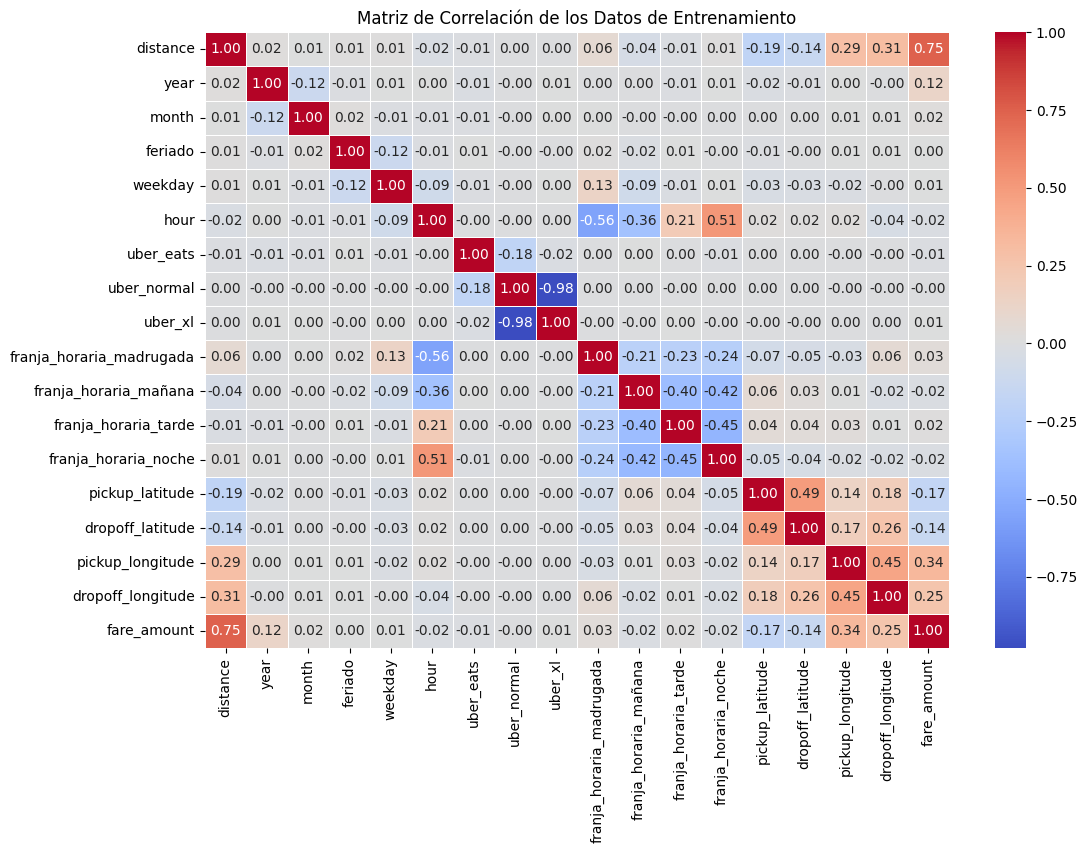

In [32]:
# Unimos X_train con y_train para poder acceder a las columnas necesarias
df_train = X_train.copy()
df_train['fare_amount'] = y_train

# Calculamos la matriz de correlación para el DataFrame de entrenamiento
corr_matrix = df_train.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=.5)
plt.title("Matriz de Correlación de los Datos de Entrenamiento")
plt.show()

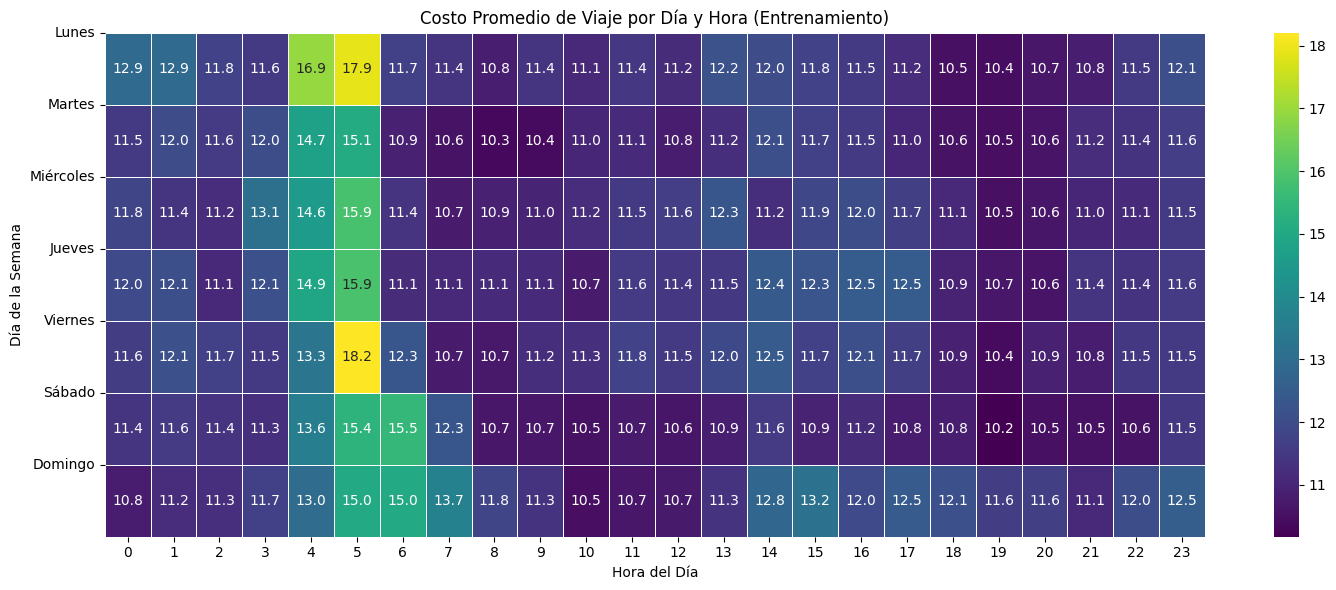

In [33]:
''' Grafico para visualizar como se van a comportar las franjas horarias y los horarios individualmente'''

# Agrupamos por día de la semana y hora y calculamos el costo promedio
viajes_por_dia_hora = df_train.groupby(['weekday', 'hour'])['fare_amount'].mean().reset_index(name='costo_promedio')

# Convertimos a formato de tabla (día como filas, hora como columnas)
tabla_heatmap = viajes_por_dia_hora.pivot(index='weekday', columns='hour', values='costo_promedio')

# Creamos el heatmap
plt.figure(figsize=(15, 6))
sns.heatmap(tabla_heatmap, cmap='viridis', annot=True, fmt=".1f", linewidths=.5)

plt.title('Costo Promedio de Viaje por Día y Hora (Entrenamiento)')
plt.xlabel('Hora del Día')
plt.ylabel('Día de la Semana')
plt.yticks(ticks=range(7), labels=['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'], rotation=0)

plt.tight_layout()
plt.show()


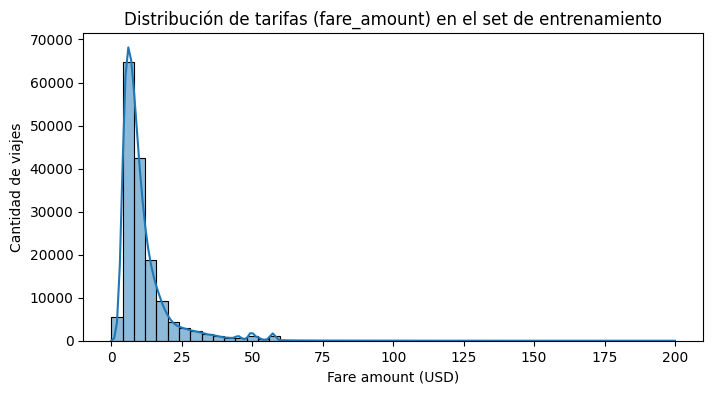

In [34]:
''' Grafico para entender la distribucion de la variable target para posterior procesamiento'''

plt.figure(figsize=(8,4))
sns.histplot(y_train, bins=50, kde=True)
plt.title("Distribución de tarifas (fare_amount) en el set de entrenamiento")
plt.xlabel("Fare amount (USD)")
plt.ylabel("Cantidad de viajes")
plt.show()

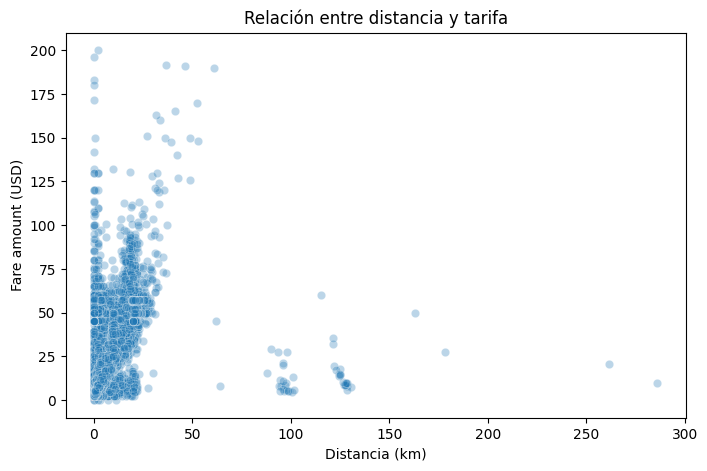

In [35]:
''' Grafico para visualizar la relacion de la variable distance y la target'''
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_train, x='distance', y='fare_amount', alpha=0.3)
plt.title("Relación entre distancia y tarifa")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare amount (USD)")
plt.show()


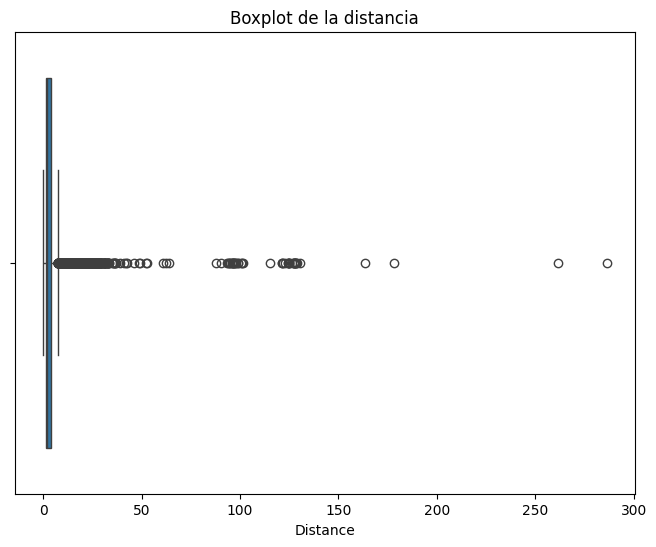

In [36]:
''' Gráfico para visualizar la distribución de la variable distancia '''
plt.figure(figsize=(8, 6))
sns.boxplot(x=X_train['distance'])
plt.title("Boxplot de la distancia")
plt.xlabel("Distance")
plt.show()

### Escalado de datos

In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reconstruir los DataFrames escalados
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)


# Ejercicio 4

### Funciones de gradiente y metricas

In [38]:
def gradient_descent_model(X_train_df, y_train_series, X_val_df, y_val_series, lr=0.01, epochs=100):
    import numpy as np
    import matplotlib.pyplot as plt

    X_train = X_train_df.values
    X_val = X_val_df.values
    y_train = y_train_series.values.reshape(-1, 1)
    y_val = y_val_series.values.reshape(-1, 1)

    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((X_val.shape[0], 1)), X_val))

    W = np.random.randn(m + 1, 1)

    train_errors = []
    val_errors = []

    for _ in range(epochs):
        y_pred_train = X_train @ W
        error_train = y_train - y_pred_train
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        y_pred_val = X_val @ W
        error_val = y_val - y_pred_val
        val_mse = np.mean(error_val ** 2)
        val_errors.append(val_mse)

        gradient = -2 / n * (X_train.T @ error_train)
        W = W - lr * gradient

    # Graficar errores
    plt.figure(figsize=(10, 5))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(val_errors, label='Error de validación')
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    plt.title('Evolución del error (GD)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return W, y_pred_train, y_pred_val, train_errors, val_errors


In [39]:
def mini_batch_gradient_descent_model(X_train_df, y_train_series, X_test_df, y_test_series, lr=0.01, epochs=100, batch_size=11):
    import numpy as np
    import matplotlib.pyplot as plt

    X_train = X_train_df.values
    X_test = X_test_df.values
    y_train = y_train_series.values.reshape(-1, 1)
    y_test = y_test_series.values.reshape(-1, 1)

    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1, 1)

    train_errors = []
    test_errors = []

    for epoch in range(epochs):
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(0, n, batch_size):
            x_batch = X_train[j:j + batch_size]
            y_batch = y_train[j:j + batch_size]

            pred_batch = x_batch @ W
            error_batch = y_batch - pred_batch
            train_mse = np.mean(error_batch ** 2)
            train_errors.append(train_mse)

            gradient = -2 * (x_batch.T @ error_batch) / batch_size
            W = W - lr * gradient

            pred_test = X_test @ W
            error_test = y_test - pred_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

    y_pred_train = X_train @ W
    y_pred_test = X_test @ W

    # Graficar errores
    plt.figure(figsize=(10, 5))
    plt.plot(train_errors, label='Error de entrenamiento (mini-batch)')
    plt.plot(test_errors, label='Error de validación')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.title('Evolución del error (Mini-Batch GD)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return W, y_pred_train, y_pred_test, train_errors, test_errors


In [40]:
def calcular_metricas_completas(modelo, X_train, y_train, X_test, y_test, nombre="Modelo"):
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)

    # TRAIN
    r2_train = r2_score(y_train, y_train_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train, y_train_pred)

    # TEST
    r2_test = r2_score(y_test, y_test_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_test_pred)

    print(f"\nMétricas para {nombre}")
    print("TRAIN:")
    print(f"  R²:   {r2_train:.3f}")
    print(f"  RMSE: {rmse_train:.2f}")
    print(f"  MAE:  {mae_train:.2f}")
    print("TEST:")
    print(f"  R²:   {r2_test:.3f}")
    print(f"  RMSE: {rmse_test:.2f}")
    print(f"  MAE:  {mae_test:.2f}")

    return {
        "modelo": nombre,
        "r2_train": r2_train, "r2_test": r2_test,
        "rmse_train": rmse_train, "rmse_test": rmse_test,
        "mae_train": mae_train, "mae_test": mae_test
    }

resultados = [] # Donde almacenaremos los resultados de cada modelo para posterior analisis


### Regresion lineal


Métricas para Linear Regression
TRAIN:
  R²:   0.593
  RMSE: 6.23
  MAE:  2.79
TEST:
  R²:   0.654
  RMSE: 5.59
  MAE:  2.71
{'modelo': 'Linear Regression', 'r2_train': 0.5930349722830959, 'r2_test': 0.6535374096770525, 'rmse_train': np.float64(6.233407753191028), 'rmse_test': np.float64(5.587246805779766), 'mae_train': 2.7934353911117915, 'mae_test': 2.7106935306545785}


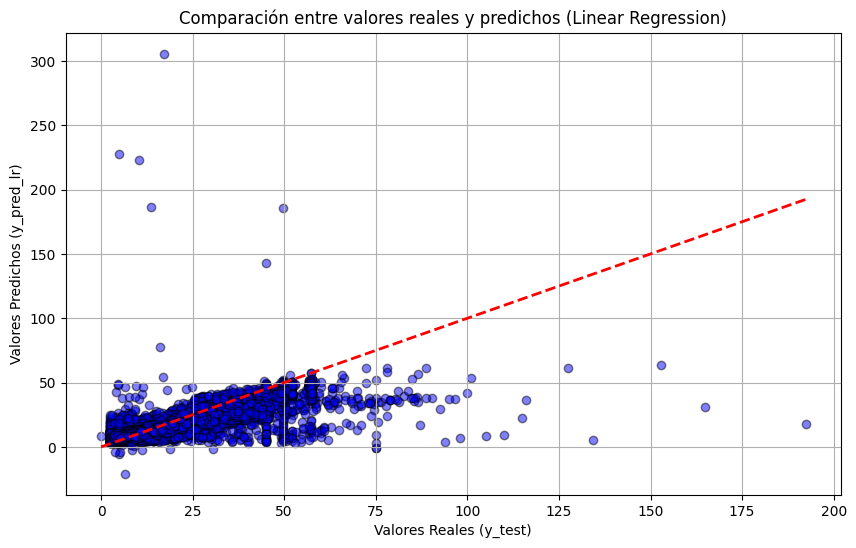

In [41]:
modelo_lr = LinearRegression()

# Lo entrenamos
modelo_lr.fit(X_train_scaled, y_train)

# Predecimos
y_pred_lr = modelo_lr.predict(X_test_scaled)

# Visualizamos métricas
resultados_lr = calcular_metricas_completas(modelo_lr, X_train_scaled, y_train, X_test_scaled, y_test, "Linear Regression")
print(resultados_lr)

resultados.append(resultados_lr)

# graficamos
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='blue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.title('Comparación entre valores reales y predichos (Linear Regression)')
plt.xlabel('Valores Reales (y_test)')
plt.ylabel('Valores Predichos (y_pred_lr)')
plt.grid(True)
plt.show()

### Gradientes

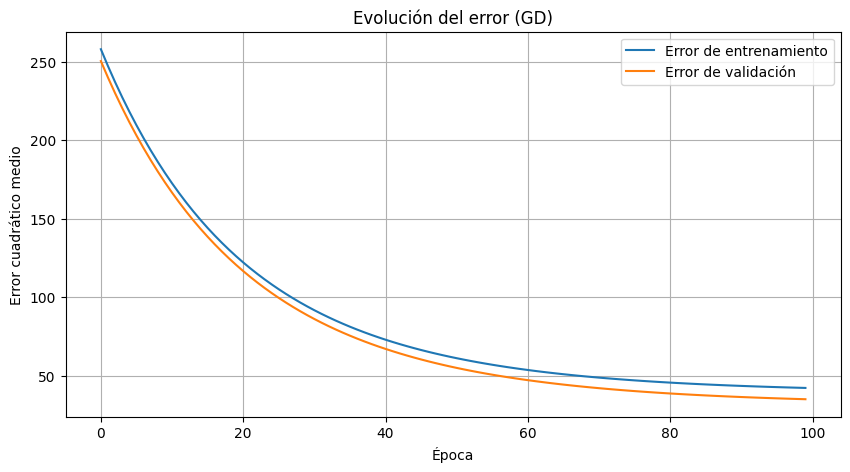

In [ ]:
# Gradiente descendiente 
W_gd, y_pred_train_gd, y_pred_test_gd, train_errors_gd, val_errors_gd = gradient_descent_model(X_train_scaled, y_train, X_test_scaled, y_test,lr=0.01, epochs=100)

# En este gráfico vemos una disminución constante del error tanto en entrenamiento como en validación, lo que indica que el modelo está aprendiendo correctamente y generaliza bien.

El modelo con Gradiente Descendente muestra un rendimiento levemente inferior al de la Regresión Lineal. Esto se nota principalmente en un menor R² y errores ligeramente más altos en ambas particiones (train y test). Esta diferencia puede deberse a que el algoritmo no alcanzó un ajuste tan fino como el método exacto de la regresión lineal, aunque los resultados siguen siendo razonables.

In [52]:

resultados_gd = {
    "modelo": "Gradient Descent",
    "r2_train": r2_score(y_train, y_pred_train_gd),
    "r2_test": r2_score(y_test, y_pred_test_gd),
    "rmse_train": np.sqrt(mean_squared_error(y_train, y_pred_train_gd)),
    "rmse_test": np.sqrt(mean_squared_error(y_test, y_pred_test_gd)),
    "mae_train": mean_absolute_error(y_train, y_pred_train_gd),
    "mae_test": mean_absolute_error(y_test, y_pred_test_gd),
}

print(resultados_gd)
resultados.append(resultados_gd)

{'modelo': 'Gradient Descent', 'r2_train': 0.5589527365578812, 'r2_test': 0.6124603353635434, 'rmse_train': np.float64(6.489176066059127), 'rmse_test': np.float64(5.90918737687873), 'mae_train': 2.943005044762294, 'mae_test': 2.8520424819452397}


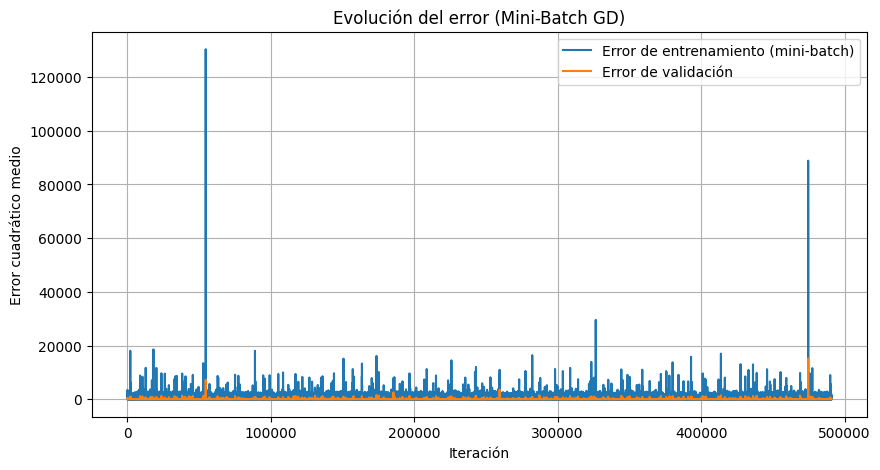

In [ ]:

#mini-batch
W_mb, y_pred_train_mb, y_pred_test_mb, train_errors_mb, test_errors_mb = mini_batch_gradient_descent_model(X_train_scaled, y_train, X_test_scaled, y_test,lr=0.01, epochs=100,batch_size=32
)

# El error de entrenamiento, calculado sobre cada mini-batch, muestra una alta variabilidad a lo largo del proceso

En este caso, el rendimiento en el conjunto de entrenamiento es más bajo en comparación con los otros modelos, con un R² reducido y errores más elevados. Sin embargo, en el conjunto de test obtiene los mejores resultados, lo que sugiere una excelente capacidad de generalización. Esto puede deberse a que el entrenamiento con mini-batch introduce cierta variabilidad en el proceso de ajuste, lo cual puede generar soluciones más robustas frente a nuevos datos.

In [51]:
resultados_mb = {
    "modelo": "Mini-Batch Gradient Descent",
    "r2_train": r2_score(y_train, y_pred_train_mb),
    "r2_test": r2_score(y_test, y_pred_test_mb),
    "rmse_train": np.sqrt(mean_squared_error(y_train, y_pred_train_mb)),
    "rmse_test": np.sqrt(mean_squared_error(y_test, y_pred_test_mb)),
    "mae_train": mean_absolute_error(y_train, y_pred_train_mb),
    "mae_test": mean_absolute_error(y_test, y_pred_test_mb),
}

print(resultados_mb)
resultados.append(resultados_mb)



{'modelo': 'Mini-Batch Gradient Descent', 'r2_train': -0.9549193234624413, 'r2_test': 0.6499626026464441, 'rmse_train': np.float64(13.661909733304848), 'rmse_test': np.float64(5.615997488432223), 'mae_train': 7.912294393057205, 'mae_test': 2.334013564622961}


In [46]:
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42, verbose=0)

# Entrenamiento del modelo usando el conjunto escalado
sgd_reg.fit(X_train_scaled, y_train)

# Predicción en el conjunto de prueba
y_pred = sgd_reg.predict(X_test_scaled)

resultados_sgd = calcular_metricas_completas(sgd_reg, X_train_scaled, y_train, X_test_scaled, y_test, "Gradiente estocastico")
print(resultados_sgd)


Métricas para Gradiente estocastico
TRAIN:
  R²:   0.558
  RMSE: 6.50
  MAE:  3.19
TEST:
  R²:   0.612
  RMSE: 5.91
  MAE:  3.10
{'modelo': 'Gradiente estocastico', 'r2_train': 0.5576512435081287, 'r2_test': 0.6119550841096741, 'rmse_train': np.float64(6.498743517043377), 'rmse_test': np.float64(5.913038146383988), 'mae_train': 3.1852216426697404, 'mae_test': 3.0969640984648663}


El gradiente estocástico tiene un rendimiento apenas inferior al de la Regresión Lineal. El R² es un poco más bajo y los errores algo mayores, pero no hay diferencias grandes. Esto es esperable, ya que este método introduce cierta variabilidad en cada iteración, lo que puede afectar la precisión final. Aun así, es una buena alternativa cuando se busca rapidez en el entrenamiento.

### Regularización

In [47]:
# Definimos y ajustamos los modelos
lassoCV = LassoCV(cv=5, max_iter=10000)
ridgeCV = RidgeCV(cv=5)
elasticnetCV = ElasticNetCV(cv=5, max_iter=10000)

# Ajustamos los modelos con el set de entrenamiento
lassoCV.fit(X_train_scaled, y_train)
ridgeCV.fit(X_train_scaled, y_train)
elasticnetCV.fit(X_train_scaled, y_train)

ElasticNetCV(cv=5, max_iter=10000)

In [ ]:
# Alphas óptimos
print("Alpha óptimo Lasso:", lassoCV.alpha_)
print("Alpha óptimo Ridge:", ridgeCV.alpha_)
print("Alpha óptimo ElasticNet:", elasticnetCV.alpha_)

Alpha óptimo Lasso: 0.033867808029261294
Alpha óptimo Ridge: 10.0
Alpha óptimo ElasticNet: 0.05494244652760071


#### Elegimos R², MAE y RMSE por las siguientes razones:

-⁠  **⁠R²** nos muestra qué tan bien el modelo explica la variabilidad de la variable objetivo.

-⁠  **⁠MAE** porque nos indica, en promedio, cuánto se equivoca el modelo, en las *mismas unidades que la variable*. Es fácil de interpretar y no se ve muy afectada por outliers.

-⁠  **⁠RMSE** también está en las mismas unidades, pero al penalizar más los errores grandes, nos ayuda a *detectar si hay outliers* que están afectando el rendimiento y en que proporción.

Evaluamos el modelo tanto en el conjunto de entrenamiento como en el de prueba para analizar su capacidad de generalización. Comparar el rendimiento en ambos conjuntos nos permite detectar si el modelo está sobreajustado (**overfitting**) o subajustado (**underfitting**), y entender si **realmente aprende patrones útiles o simplemente memoriza los datos de entrenamiento**.

#### ¿Creen que lograron un buen fitting?

Sí, consideramos que se logró un buen fitting. Los valores de **R², RMSE y MAE** en el conjunto de test indican que el **modelo generaliza bien y logra capturar una parte importante de la variabilidad de los datos**. Si bien con un tratamiento algo distinto podríamos haber obtenido una mejora leve, es poco probable que los resultados cambien de forma significativa.

# Ejercicio 5
--------

#### Gradiente Descendente (GD)

- **Learning rate muy alto**:

Cuando la tasa de aprendizaje es demasiado grande, el modelo puede saltar alrededor del mínimo en lugar de acercarse de forma estable. Esto genera oscilaciones en el error o *incluso hace que no converja*.

- **Learning rate muy bajo**:

Si es demasiado bajo, el modelo avanza muy lento. Puede requerir muchas épocas para alcanzar un buen resultado, lo cual *implica mayor tiempo de entrenamiento*.

- **Pocas épocas**:

Si el número de épocas es insuficiente, el modelo no llega a aprender bien los patrones de los datos. Esto suele resultar en **underfitting**, tanto en entrenamiento como en test.

- **Demasiadas épocas**:

Si ya alcanzó un buen punto y se sigue entrenando, no mejora mucho más y puede terminar sobreajustando, es decir, aprendiendo demasiado bien los datos de entrenamiento y **perdiendo capacidad de generalización**.

#### Lasso y Ridge (regularización)

- **Alpha muy alto**:

Penaliza tanto los coeficientes que el modelo queda demasiado simple. Se le escapan patrones importantes y eso lleva a underfitting.

- **Alpha muy bajo**:
La penalización es mínima, así que *el modelo se parece mucho a una regresión sin regularización*. Si hay mucho ruido o variables de más, puede terminar en overfitting.

# Ejercicio 6
-----

### Comparacion de modelos

In [ ]:
resultados = []

resultados.append(calcular_metricas_completas(modelo_lr, X_train_scaled, y_train, X_test_scaled, y_test, "Linear Regression"))
resultados.append(calcular_metricas_completas(ridgeCV, X_train_scaled, y_train, X_test_scaled, y_test, "RidgeCV"))
resultados.append(calcular_metricas_completas(lassoCV, X_train_scaled, y_train, X_test_scaled, y_test, "LassoCV"))
resultados.append(calcular_metricas_completas(elasticnetCV, X_train_scaled, y_train, X_test_scaled, y_test, "ElasticNetCV"))
resultados.append(resultados_gd)  # Gradiente Descendente Normal
resultados.append(resultados_mb)  # Gradiente Descendente Mini-Batch
resultados.append(resultados_sgd)  # Gradiente Descendente Estocástico

tabla_resultados = pd.DataFrame(resultados)
display(tabla_resultados)


Métricas para Linear Regression
TRAIN:
  R²:   0.593
  RMSE: 6.23
  MAE:  2.79
TEST:
  R²:   0.654
  RMSE: 5.59
  MAE:  2.71

Métricas para RidgeCV
TRAIN:
  R²:   0.593
  RMSE: 6.23
  MAE:  2.79
TEST:
  R²:   0.654
  RMSE: 5.59
  MAE:  2.71

Métricas para LassoCV
TRAIN:
  R²:   0.593
  RMSE: 6.23
  MAE:  2.80
TEST:
  R²:   0.654
  RMSE: 5.59
  MAE:  2.72

Métricas para ElasticNetCV
TRAIN:
  R²:   0.592
  RMSE: 6.24
  MAE:  2.85
TEST:
  R²:   0.650
  RMSE: 5.61
  MAE:  2.77


,modelo,r2_train,r2_test,rmse_train,rmse_test,mae_train,mae_test
0,Linear Regression,0.593035,0.653537,6.233408,5.587247,2.793435,2.710694
1,RidgeCV,0.593035,0.653532,6.233408,5.587288,2.793558,2.710817
2,LassoCV,0.592874,0.653791,6.234640,5.585198,2.800116,2.717578
3,ElasticNetCV,0.592446,0.650493,6.237914,5.611745,2.853904,2.771313
4,Gradient Descent,0.558953,0.612460,6.489176,5.909187,2.943005,2.852042
5,Mini-Batch Gradient Descent,-0.954919,0.649963,13.661910,5.615997,7.912294,2.334014
6,Gradiente estocastico,0.557651,0.611955,6.498744,5.913038,3.185222,3.096964


Nos basamos en **R2** para comparar los modelos, ya que es la de métrica que más fácil se puede interpretar y al compararlo en el set de test podemos ver *como se comporta el modelo con datos no vistos* y nos permite detectar *si existe overfitting o underfitting*. Por todo esto, el mejor modelo es **LassoCV**.

# Ejercicio 7
-----

### Conclusión

Llegamos a la conclusión de que las **variables más relevantes** para predecir el precio del viaje son la distancia, las distintas **medidas de ubicación geográfica**, y el año. Este último podría estar capturando un *efecto inflacionario o un aumento progresivo en las tarifas*, posiblemente asociado a una menor competencia en el mercado y una tendencia hacia la concentración (monopolio u oligopolio), lo cual impactaría en el precio promedio de los viajes.

En cuanto a los modelos de regresión utilizados, Lasso y Ridge ofrecieron *resultados muy similares al de Regresión Lineal* en las métricas evaluadas, lo que sugiere que la selección de variables que hicimos desde el inicio fue bastante acertada.

Consideramos que una de las principales limitaciones del modelo fue la falta de ciertas variables clave que podrían haber mejorado significativamente el rendimiento, como la duración del viaje, la relación entre oferta y demanda en el momento de la solicitud, y posibles relaciones no lineales entre variables que los modelos lineales no logran capturar. Además, creemos que un tratamiento distinto de outliers y valores erróneos podría haber aportado una leve mejora adicional en la precisión de las predicciones.